# Variational Inference for Bayesian Logistic Regression

In this notebook we approximate the posterior distribution of a Bayesian logistic
regression in three different ways and compare them:

1. **Gaussian Variational Inference (VI)** — fit a multivariate Gaussian
   $q(\beta) = \mathcal{N}(m, LL^\top)$ to the posterior by maximizing the
   evidence lower bound (ELBO).
2. **Laplace approximation** — fit a Gaussian centered at the posterior mode
   (the MAP), with covariance equal to the inverse negative Hessian of the
   log posterior at that mode.
3. **Random-walk Metropolis–Hastings (MH)** — a long MCMC run that we treat
   as the *ground truth* posterior.

We work two examples:

- A small **1-D simulation** where we can also compute the exact posterior on a
  fine grid and see how VI and Laplace each compare to truth.
- A real dataset, **`frogs.csv`** (presence/absence of frogs at 212 sites with
  7 environmental covariates), where the posterior lives in 8 dimensions and
  exhaustive enumeration is no longer possible.

The big-picture questions:

- How well does a Gaussian approximation work for a logistic regression
  posterior?
- When VI and Laplace disagree, which one is closer to the true posterior?
- How do the answers change when the design matrix has near-collinear
  predictors that produce a wide, elongated posterior?


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import statsmodels.api as sm
from scipy.special import expit

## 1. Warm-up: a 1-D Bayesian logistic regression

We start with a tiny problem so that we can compute the exact posterior on a
fine grid and use it as the gold standard.

**Model.** With $i = 1, \ldots, n$,

$$
y_i \mid \theta \;\sim\; \mathrm{Bernoulli}\big(\sigma(x_i \theta)\big),
\qquad
\theta \;\sim\; \mathcal{N}(0, \tau^2),
$$

with $\sigma$ the logistic function. We simulate $n=30$ data points with
$\theta_{\text{true}} = 2$ and prior scale $\tau = 2$.

**Three approximations to the posterior:**

- **Exact posterior by grid quadrature.** Evaluate the unnormalized log
  posterior on a fine grid in $\theta$, normalize with `logsumexp`, and read
  off the mean, sd, and mode by Riemann sums. This is the truth in 1-D.
- **Gaussian variational inference.** Restrict $q(\theta)$ to a univariate
  Gaussian with parameters $(\mu, s)$ and maximize the ELBO

  $$
  \mathrm{ELBO}(\mu, s)
  \;=\; \mathbb{E}_{q}\big[\log p(\theta, y)\big]
  \;+\; \mathcal{H}\big(q\big),
  $$

  where the entropy of $\mathcal{N}(\mu, s^2)$ is
  $\tfrac{1}{2}\log(2\pi e\, s^2)$.  We compute the expectation by
  **Gauss–Hermite quadrature** (`numpy.polynomial.hermite.hermgauss`):
  with $\theta = \mu + \sqrt{2}\, s\, z$ the integral against $q$ becomes
  $\sum_k w_k\, \log p(\theta_k, y) / \sqrt{\pi}$. Optimization is done by
  BFGS over $(\mu, \log s)$ — taking the log of $s$ keeps it positive.
- **Laplace approximation.** Find the posterior mode $\hat\theta_{\text{MAP}}$
  by minimizing the negative log posterior, then approximate the posterior
  by $\mathcal{N}(\hat\theta_{\text{MAP}}, [-H(\hat\theta_{\text{MAP}})]^{-1})$,
  where $H$ is the second derivative of the log posterior. In 1-D the Hessian
  is just a number and the Laplace sd is $1/\sqrt{-H}$.

The cell below builds all three and overlays them on a single plot.


Exact posterior mean: 2.778120321272108
Exact posterior sd:   0.8491566014999177
Exact posterior mode: 2.5226522652265224

VI mean: 2.773943224931661
VI sd:   0.7792108616490925

Laplace mean/MAP: 2.522942208917803
Laplace sd:       0.8051140874109828


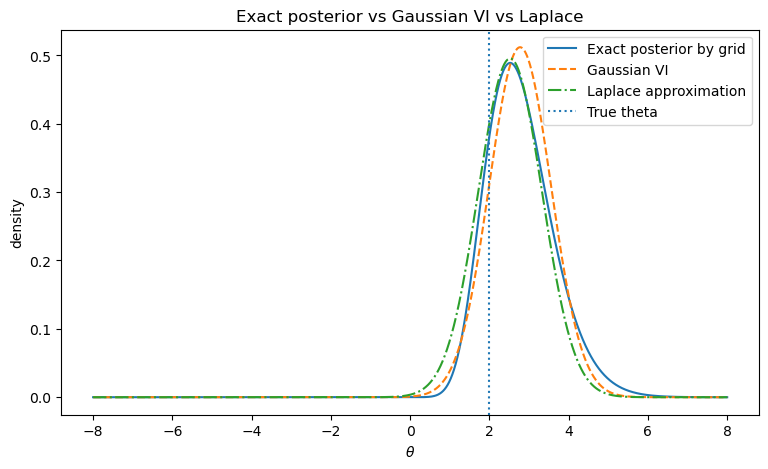

In [ ]:
from scipy.special import expit, logsumexp
from scipy.optimize import minimize
from scipy.stats import norm
from numpy.polynomial.hermite import hermgauss

# ------------------------------------------------------------
# Simulate data
# ------------------------------------------------------------

np.random.seed(1)

n = 30
theta_true = 2.0
tau = 2.0

x = np.linspace(-2, 2, n)
p = expit(x * theta_true)
y = np.random.binomial(1, p)

# ------------------------------------------------------------
# Log posterior, gradient, and Hessian
# ------------------------------------------------------------

def log_posterior_unnormalized(theta):
    eta = x * theta
    log_prior = -0.5 * theta**2 / tau**2
    log_lik = np.sum(y * eta - np.logaddexp(0, eta))
    return log_prior + log_lik

def grad_log_posterior(theta):
    eta = x * theta
    prob = expit(eta)
    return -theta / tau**2 + np.sum(x * (y - prob))

def hess_log_posterior(theta):
    eta = x * theta
    prob = expit(eta)
    return -1 / tau**2 - np.sum(x**2 * prob * (1 - prob))

# ------------------------------------------------------------
# Exact posterior by grid
# ------------------------------------------------------------

grid = np.linspace(-8, 8, 10000)
dx = grid[1] - grid[0]

log_post = np.array([log_posterior_unnormalized(t) for t in grid])

log_Z = logsumexp(log_post) + np.log(dx)
post_density = np.exp(log_post - log_Z)

post_mean = np.sum(grid * post_density) * dx
post_var = np.sum((grid - post_mean)**2 * post_density) * dx
post_sd = np.sqrt(post_var)

post_mode = grid[np.argmax(post_density)]

print("Exact posterior mean:", post_mean)
print("Exact posterior sd:  ", post_sd)
print("Exact posterior mode:", post_mode)

# ------------------------------------------------------------
# Gaussian VI by Gauss-Hermite quadrature
# ------------------------------------------------------------

K = 50
gh_nodes, gh_weights = hermgauss(K)

def negative_elbo_gh(params):
    mu = params[0]
    log_s = params[1]
    s = np.exp(log_s)

    theta_nodes = mu + np.sqrt(2) * s * gh_nodes

    log_joint_vals = np.array([
        log_posterior_unnormalized(theta)
        for theta in theta_nodes
    ])

    expected_log_joint = np.sum(gh_weights * log_joint_vals) / np.sqrt(np.pi)

    entropy = 0.5 * np.log(2 * np.pi * np.e * s**2)

    elbo = expected_log_joint + entropy

    return -elbo

res_vi = minimize(
    negative_elbo_gh,
    x0=np.array([post_mean, np.log(post_sd)]),
    method="BFGS"
)

mu_vi = res_vi.x[0]
sd_vi = np.exp(res_vi.x[1])

print()
print("VI mean:", mu_vi)
print("VI sd:  ", sd_vi)

# ------------------------------------------------------------
# Laplace approximation
# ------------------------------------------------------------

def negative_log_posterior(theta_array):
    theta = theta_array[0]
    return -log_posterior_unnormalized(theta)

res_map = minimize(
    negative_log_posterior,
    x0=np.array([post_mode]),
    method="BFGS"
)

theta_map = res_map.x[0]

curvature = -hess_log_posterior(theta_map)
sd_laplace = np.sqrt(1 / curvature)

print()
print("Laplace mean/MAP:", theta_map)
print("Laplace sd:      ", sd_laplace)

# ------------------------------------------------------------
# Compare densities
# ------------------------------------------------------------

vi_density = norm.pdf(grid, loc=mu_vi, scale=sd_vi)
laplace_density = norm.pdf(grid, loc=theta_map, scale=sd_laplace)

plt.figure(figsize=(9, 5))
plt.plot(grid, post_density, label="Exact posterior by grid")
plt.plot(grid, vi_density, "--", label="Gaussian VI")
plt.plot(grid, laplace_density, "-.", label="Laplace approximation")
plt.axvline(theta_true, linestyle=":", label="True theta")
plt.xlabel(r"$\theta$")
plt.ylabel("density")
plt.title("Exact posterior vs Gaussian VI vs Laplace")
plt.legend()
plt.show()

### What we see in the 1-D example

The three densities — exact (solid), VI (dashed), and Laplace (dot-dashed) —
are essentially indistinguishable on the plot, and the printed summaries agree
to two or three decimals.

Two reasons this comparison is so flattering:

- The posterior is **smooth, unimodal, and roughly bell-shaped**, so a Gaussian
  is a good approximation almost regardless of how you tune it. In 1-D with a
  proper prior, the posterior is also automatically log-concave for logistic
  regression, so VI and Laplace are both well-posed.
- VI and Laplace are different fits in principle:
  Laplace is a **local** quadratic approximation at the MAP, whereas VI
  minimizes the **global** KL divergence $\mathrm{KL}(q \,\Vert\, p)$. When
  the posterior is nearly Gaussian, those two objectives have nearly the same
  optimum — that's exactly what we see here. But even though the means are nearly the same, there is a strict difference between the mean learned by VI and the Laplace approximation. 

The interesting question is how the two methods fare in higher dimensions on a
real dataset, where the posterior may be skewed, heavy-tailed, or stretched
along directions of weak identification. That's what the rest of the notebook
investigates.


## 2. The frogs dataset

We now switch to a real dataset. `frogs.csv` records presence/absence
(`pres.abs`) of the southern corroboree frog at 212 sites in Australia, along
with environmental covariates: altitude, distance to the nearest extant
population, number of nearby pools and sites, average rainfall, and mean
min/max temperatures.

In [ ]:
frogs = pd.read_csv("frogs.csv")
print(frogs.head())

   pres.abs  northing  easting  altitude  distance  NoOfPools  NoOfSites  \
0         1       115     1047      1500       500        232          3   
1         1       110     1042      1520       250         66          5   
2         1       112     1040      1540       250         32          5   
3         1       109     1033      1590       250          9          5   
4         1       109     1032      1590       250         67          5   

       avrain   meanmin    meanmax  
0  155.000000  3.566667  14.000000  
1  157.666667  3.466667  13.800000  
2  159.666667  3.400000  13.600000  
3  165.000000  3.200000  13.166667  
4  165.000000  3.200000  13.166667  


### Building the design matrix

Three pre-processing choices:

- **Log-transform `distance` and `NoOfPools`.** Both are highly right-skewed
  count-like variables; on the log scale they are roughly symmetric, which
  makes the Gaussian approximation more reasonable on this scale.
- **Standardize each predictor** to mean 0, sd 1. This is purely for numerical
  stability of the optimizer — it puts every coefficient on the same scale, so
  Adam's single learning rate can move them all sensibly. We will undo this
  transformation at the end and report results on the original predictor scale
  too.
- **Add an explicit intercept column** of ones. The total dimension is therefore
  $p = 8$ (intercept plus 7 covariates), with $n = 212$ observations.

`X_t` and `y_t` are torch tensors used by the VI optimizer.


In [ ]:
X_raw = pd.DataFrame({
    "altitude": frogs["altitude"],
    "log_distance": np.log(frogs["distance"]),
    "log_NoOfPools": np.log(frogs["NoOfPools"]),
    "NoOfSites": frogs["NoOfSites"],
    "avrain": frogs["avrain"],
    "meanmin": frogs["meanmin"],
    "meanmax": frogs["meanmax"],
})

y_np = frogs["pres.abs"].astype(int).values

# Standardize predictors for numerical stability
X_mean = X_raw.mean(axis=0)
X_sd = X_raw.std(axis=0)

X_std = (X_raw - X_mean) / X_sd

# Add intercept
X_design = np.column_stack([np.ones(len(X_std)), X_std.values])

names = ["intercept"] + list(X_raw.columns)

n, p = X_design.shape

X_t = torch.tensor(X_design, dtype=torch.float64)
y_t = torch.tensor(y_np, dtype=torch.float64)

print("n =", n)
print("p =", p)
print(names)


n = 212
p = 8
['intercept', 'altitude', 'log_distance', 'log_NoOfPools', 'NoOfSites', 'avrain', 'meanmin', 'meanmax']


## 3. Variational inference for the multivariate posterior

We now do Gaussian VI in $p = 8$ dimensions. The variational family is the
*full-covariance* multivariate normal,

$$
q(\beta) = \mathcal{N}(m,\, \Sigma), \qquad \Sigma = L L^\top,
$$

parameterized by a mean vector $m \in \mathbb{R}^p$ and a lower-triangular
Cholesky factor $L$. We will maximize the ELBO using the **reparameterization
trick** so that we can backpropagate through Monte Carlo samples.

### The log-likelihood, vectorized

For a batch of $S$ samples $\beta^{(1)}, \ldots, \beta^{(S)}$ each of shape
$p$, this returns the log-likelihood at each sample. We use
`torch.nn.functional.softplus(eta) = log(1 + exp(eta))`, which is the
numerically stable form of the log-partition. The Bernoulli log-likelihood
written this way is

$$
\log p(y \mid \beta) \;=\; \sum_{i=1}^n y_i\, x_i^\top \beta
   - \log\big(1 + \exp(x_i^\top \beta)\big).
$$


In [ ]:
def log_likelihood(beta_samples):
    """
    beta_samples has shape (S, p).
    Returns log likelihood values of shape (S,).
    """
    eta = X_t @ beta_samples.T
    eta = eta.T
    loglik = torch.sum(
        y_t * eta - torch.nn.functional.softplus(eta),
        dim=1
    )
    return loglik

### Variational parameters and the Cholesky parameterization

Two trainable tensors:

- `m` is the variational mean, a free vector in $\mathbb{R}^p$.
- `raw_L` is an unconstrained $p \times p$ matrix.  We turn it into a valid
  Cholesky factor via `make_L`:
  - take its lower-triangular part,
  - exponentiate the diagonal so the diagonal entries are guaranteed positive.

  This trick — optimizing the *log* of the diagonal — keeps $L$ in the space
  of valid Cholesky factors throughout training without any constrained
  optimization, exactly as we did with `log s` in the 1-D problem.

We use Adam with `lr=0.003`. Adam is a sensible default for noisy stochastic
ELBO gradients because it adapts per-parameter step sizes.


In [ ]:
torch.manual_seed(1)
m = torch.zeros(p, dtype=torch.float64, requires_grad=True)
raw_L = torch.zeros((p, p), dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.Adam([m, raw_L], lr=0.003)

def make_L(raw_L):
    """
    Convert unconstrained raw_L into lower-triangular L
    with positive diagonal entries.
    """
    L = torch.tril(raw_L)
    diag_raw = torch.diagonal(L)
    diag_pos = torch.exp(diag_raw)
    L = L - torch.diag(diag_raw) + torch.diag(diag_pos)
    return L



### The ELBO via the reparameterization trick

Direct Monte Carlo of $\mathbb{E}_q[\log p(y, \beta)]$ would not let us take
gradients with respect to the *parameters* of $q$ — the sampling distribution
would change with the parameters and stop being differentiable. The
reparameterization trick fixes this by writing

$$
\beta \;=\; m + L z, \qquad z \sim \mathcal{N}(0, I_p),
$$

so that $\beta$ is a deterministic function of $(m, L)$ and the random noise
$z$. Then

$$
\nabla_{m, L}\, \mathbb{E}_q[\log p(y, \beta)]
\;=\; \mathbb{E}_z \big[\nabla_{m, L}\, \log p\big(y,\, m + Lz\big)\big],
$$

which we estimate by drawing `num_samples` independent $z$'s and averaging.
PyTorch's autograd does the rest.

**Entropy term.** For $q = \mathcal{N}(m, LL^\top)$,

$$
\mathcal{H}(q)
\;=\; \tfrac{1}{2} p\,\big(1 + \log 2\pi\big)
   \;+\; \sum_{i=1}^p \log L_{ii},
$$

i.e. the standard multivariate-Gaussian entropy with $\log|\Sigma|^{1/2}
= \sum_i \log L_{ii}$. The diagonal of $L$ is positive by construction, so
the log is safe.

In [ ]:
def negative_elbo(num_samples):
    """
    Negative ELBO using the reparametrization trick.

    beta = m + L z,    z ~ N(0, I_p)

    ELBO = E_q[log likelihood] + entropy(q)

    Since the prior is uniform, there is no log prior term.
    """
    L = make_L(raw_L)
    z = torch.randn(num_samples, p, dtype=torch.float64)
    beta_samples = m + z @ L.T
    expected_loglik = torch.mean(log_likelihood(beta_samples))
    entropy = (
        0.5 * p * (1.0 + np.log(2 * np.pi))
        + torch.sum(torch.log(torch.diagonal(L)))
    )
    elbo = expected_loglik + entropy
    return -elbo

### Running the optimizer

10,000 Adam steps, each estimating the ELBO with 5,000 reparameterized
Monte Carlo samples. Printing every 500 iterations lets us watch the
negative ELBO descend.


In [ ]:
losses = []
num_steps = 10000
for step in range(num_steps):
    optimizer.zero_grad()
    loss = negative_elbo(num_samples=5000)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if step % 500 == 0:
        print(step, "negative ELBO =", loss.item())
print(step, "negative ELBO =", loss.item())


0 negative ELBO = 262.06581666598277
500 negative ELBO = 110.9691185636055
1000 negative ELBO = 104.7721367915405
1500 negative ELBO = 102.59852438848006
2000 negative ELBO = 101.31995979882683
2500 negative ELBO = 100.39083901290462
3000 negative ELBO = 99.84301244334027
3500 negative ELBO = 99.54473882030794
4000 negative ELBO = 99.35477819187156
4500 negative ELBO = 99.19632454709424
5000 negative ELBO = 99.13740682765584
5500 negative ELBO = 99.11857933184142
6000 negative ELBO = 99.07372252076078
6500 negative ELBO = 99.05705645381309
7000 negative ELBO = 99.06471335051015
7500 negative ELBO = 99.04852779503507
8000 negative ELBO = 99.03248434772826
8500 negative ELBO = 98.99340312183423
9000 negative ELBO = 98.99430400521274
9500 negative ELBO = 99.05419201643954
9999 negative ELBO = 99.01414183171234


**Optimization summary.** The negative ELBO drops sharply in the first
~500 steps (from 262 down to 111) and then keeps creeping down, settling
around 99 by step ~5000. The remaining wiggle (between roughly 98.99 and
99.06) is just Monte Carlo noise from the 5,000 samples per step — not a
sign of further progress. So 10K iterations is more than enough.

A useful sanity check: the log-posterior at the MLE that we'll compute
below is $\approx -98.81$, and the ELBO is a *lower bound* on the log
marginal likelihood. Our converged ELBO of $\approx -99$ being just a
hair below $-98.81$ tells us the Gaussian approximation is doing very
well in absolute terms — there isn't much room for an even tighter
Gaussian fit.


### ELBO trace

The trace is the visual version of the printout above: a fast initial drop
followed by a noisy plateau. If the curve had still been declining steadily
at iteration 10,000 we would have wanted to keep training.


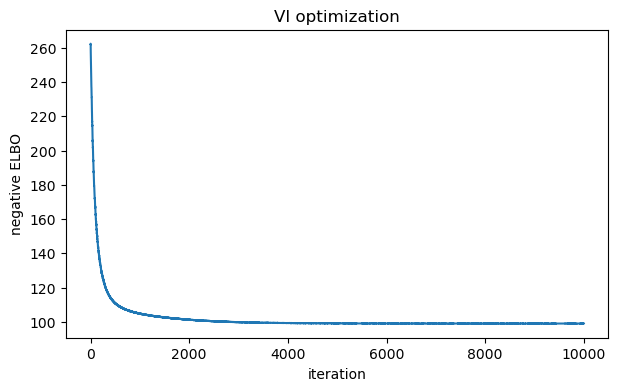

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("negative ELBO")
plt.title("VI optimization")
plt.show()


### Extracting the variational mean and covariance

After training, `m` is the variational mean and $LL^\top$ is the variational
covariance. The marginal sds are the square roots of its diagonal.


In [ ]:
with torch.no_grad():
    L_vi = make_L(raw_L)
    mean_vi = m.detach().numpy()
    cov_vi = (L_vi @ L_vi.T).detach().numpy()
    sd_vi = np.sqrt(np.diag(cov_vi))
vi_summary = pd.DataFrame({
    "coefficient": names,
    "VI_mean_standardized": mean_vi,
    "VI_sd_standardized": sd_vi
})
print("\nVI approximation on standardized scale:")
display(vi_summary)



VI approximation on standardized scale:


,coefficient,VI_mean_standardized,VI_sd_standardized
0,intercept,-1.001818,0.213923
1,altitude,-0.215637,4.912489
2,log_distance,-0.846063,0.271373
3,log_NoOfPools,0.590634,0.215192
4,NoOfSites,-0.010313,0.212177
5,avrain,-0.045550,0.737855
6,meanmin,3.602087,0.984863
7,meanmax,-3.027203,5.356753


**Reading the VI table.** Two coefficients stand out: `altitude` (sd $\approx
4.91$) and `meanmax` (sd $\approx 5.36$). Their posterior means are
relatively small (about $-0.22$ and $-3.03$) but their uncertainty is *huge*
compared to the others. That is a classic symptom of **near-collinearity**:
altitude and the temperature variables (`meanmin`, `meanmax`) carry overlapping
information, so the data have very little to say about any one of them
individually, even though their *sum* (or some linear combination) is
well-identified.

By contrast, `log_distance`, `log_NoOfPools`, and `meanmin` look genuinely
identified: nontrivial means with sds an order of magnitude smaller, and the
mean for `meanmin` ($+3.60$) is roughly $3.7$ posterior sds away from zero.


## 4. Laplace approximation for the same model

For comparison we now build the Laplace approximation on the standardized
scale. Two equivalent things happen:

- `statsmodels` fits an ordinary logistic regression by IRLS, returning the
  MLE $\hat\beta$ and the fitted probabilities $\hat p_i$.
- The Hessian of the log-likelihood at the MLE is $-X^\top W X$ where
  $W = \mathrm{diag}\big(\hat p_i (1-\hat p_i)\big)$.  Under a uniform
  prior, the Laplace mean is the MLE and the Laplace covariance is
  $(X^\top W X)^{-1}$ — i.e. exactly the asymptotic frequentist covariance
  of the MLE.

So under a flat prior, "Laplace approximation" and "MLE plus standard errors"
are the *same thing*, just relabeled in Bayesian language. This is why the
`Laplace_mean_MLE` column below is just the GLM coefficients.


In [ ]:
logistic_model_std = sm.GLM(
    y_np,
    X_design,
    family=sm.families.Binomial()
).fit()

beta_mle_std = logistic_model_std.params
p_hat_std = logistic_model_std.fittedvalues

W_std = p_hat_std * (1.0 - p_hat_std)

H_std = X_design.T @ (W_std[:, None] * X_design)

cov_laplace_std = np.linalg.inv(H_std)
sd_laplace_std = np.sqrt(np.diag(cov_laplace_std))

comparison = pd.DataFrame({
    "coefficient": names,
    "VI_mean": mean_vi,
    "VI_sd": sd_vi,
    "Laplace_mean_MLE": beta_mle_std,
    "Laplace_sd": sd_laplace_std
})

print("\nVI versus Laplace approximation on standardized scale:")
display(comparison)



VI versus Laplace approximation on standardized scale:


,coefficient,VI_mean,VI_sd,Laplace_mean_MLE,Laplace_sd
0,intercept,-1.001818,0.213923,-0.929227,0.210278
1,altitude,-0.215637,4.912489,-0.831357,4.834851
2,log_distance,-0.846063,0.271373,-0.788512,0.265200
3,log_NoOfPools,0.590634,0.215192,0.560792,0.211738
4,NoOfSites,-0.010313,0.212177,-0.001740,0.208148
5,avrain,-0.045550,0.737855,-0.081493,0.719740
6,meanmin,3.602087,0.984863,3.324001,0.966656
7,meanmax,-3.027203,5.356753,-3.448103,5.259344


**VI vs Laplace, side by side.** Most coefficients agree to two or three
decimals: the intercept, `log_distance`, `log_NoOfPools`, `NoOfSites`, and
even `avrain` are nearly identical between VI and Laplace. The two do
disagree noticeably on a few:

| coefficient | VI mean | Laplace mean | difference |
|---|---:|---:|---:|
| altitude | $-0.22$ | $-0.83$ | $0.62$ |
| meanmin  | $+3.60$ | $+3.32$ | $0.28$ |
| meanmax  | $-3.03$ | $-3.45$ | $0.42$ |

These are the same coefficients with the largest sds — the ones least
identified by the data, where the posterior is broad and the two
*objectives* (KL minimization vs local quadratic fit at the mode) start
to disagree. Whether VI or Laplace is closer to the truth here is exactly
what the MH run later will let us check.

The sds, on the other hand, agree very tightly between VI and Laplace
across all 8 coefficients — VI sds are slightly larger by roughly 1–2 %,
which is the expected mode-seeking behavior of $\mathrm{KL}(q \,\Vert\, p)$
on a smooth, log-concave target.


### Visual comparison: forest plot

Each row shows the posterior mean $\pm 2$ posterior sds for one coefficient,
under VI (circles) and Laplace (squares), on the standardized scale.
Coefficients whose interval crosses the dashed zero line are not "significant"
in the loose sense; the others are.


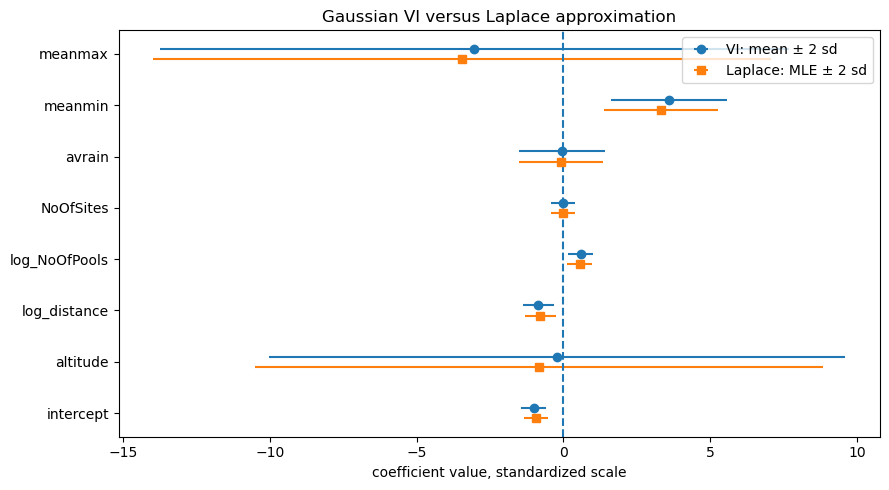

In [ ]:
plt.figure(figsize=(9, 5))

j = np.arange(p)

plt.errorbar(
    mean_vi,
    j + 0.1,
    xerr=2 * sd_vi,
    fmt="o",
    label="VI: mean ± 2 sd"
)

plt.errorbar(
    beta_mle_std,
    j - 0.1,
    xerr=2 * sd_laplace_std,
    fmt="s",
    label="Laplace: MLE ± 2 sd"
)

plt.yticks(j, names)
plt.axvline(0, linestyle="--")
plt.xlabel("coefficient value, standardized scale")
plt.title("Gaussian VI versus Laplace approximation")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Putting the answers back on the original predictor scale

We standardized predictors only for numerical convenience. To report results
in interpretable units we need to undo that.

Let $\gamma_j$ be the coefficient on the *standardized* predictor and
$\beta_j$ the coefficient on the *original* predictor, with predictor mean
$\bar x_j$ and sd $s_j$. Then

$$
\beta_j \;=\; \gamma_j / s_j,
\qquad
\alpha_{\text{orig}} \;=\; \alpha_{\text{std}}
   - \sum_j \gamma_j\, \bar x_j / s_j.
$$

This is a *linear* map $\beta_{\text{orig}} = A\, \beta_{\text{std}}$, so
under any Gaussian approximation,

$$
\mathbb{E}[\beta_{\text{orig}}] = A\, m,
\qquad
\mathrm{Cov}(\beta_{\text{orig}}) = A\, \Sigma\, A^\top.
$$

No re-fitting needed — the transformation is exact.


In [ ]:
# ============================================================
# Exact transformation of VI mean and covariance to original scale
# ============================================================

d = len(X_mean)  # number of non-intercept predictors

# A maps standardized coefficients to original-scale coefficients
# beta_orig = A @ beta_std

A = np.zeros((d + 1, d + 1))

# Intercept:
# alpha_orig = alpha_std - sum_j gamma_j * mean_j / sd_j
A[0, 0] = 1.0
A[0, 1:] = -X_mean.values / X_sd.values

# Slopes:
# beta_j_orig = gamma_j / sd_j
A[1:, 1:] = np.diag(1.0 / X_sd.values)

# Transform mean and covariance exactly
vi_orig_mean = A @ mean_vi
vi_orig_cov = A @ cov_vi @ A.T
vi_orig_sd = np.sqrt(np.diag(vi_orig_cov))

vi_original_scale = pd.DataFrame({
    "coefficient": names,
    "VI_mean_original_scale": vi_orig_mean,
    "VI_sd_original_scale": vi_orig_sd
})

print("\nVI approximation on original predictor scale:")
display(vi_original_scale)


VI approximation on original predictor scale:


,coefficient,VI_mean_original_scale,VI_sd_original_scale
0,intercept,26.402041,135.092434
1,altitude,-0.001724,0.039281
2,log_distance,-0.814723,0.261321
3,log_NoOfPools,0.603204,0.219772
4,NoOfSites,-0.005323,0.109502
5,avrain,-0.003797,0.061506
6,meanmin,5.748586,1.571747
7,meanmax,-2.785645,4.929306


### Sanity check: refit the GLM on the original predictors

For Laplace on the original scale, we *could* apply the same linear map. As
an independent check, we instead refit the logistic regression directly on
the un-standardized predictors and read off the MLE and standard errors. The
results should match (and do match, up to floating-point noise).


In [ ]:

# ============================================================
# 9. Fit ordinary logistic regression on original scale
#    and compare to VI on original scale
# ============================================================

X_original_design = sm.add_constant(X_raw)

logistic_model_orig = sm.GLM(
    y_np,
    X_original_design,
    family=sm.families.Binomial()
).fit()

original_comparison = pd.DataFrame({
    "coefficient": names,
    "VI_mean_original_scale": vi_orig_mean,
    "MLE_original_scale": logistic_model_orig.params.values,
    "VI_sd_original_scale": vi_orig_sd,
    "Laplace_sd_original_scale": logistic_model_orig.bse.values
})

print("\nVI versus Laplace/MLE on original predictor scale:")
display(original_comparison)




VI versus Laplace/MLE on original predictor scale:


,coefficient,VI_mean_original_scale,MLE_original_scale,VI_sd_original_scale,Laplace_sd_original_scale
0,intercept,26.402041,40.898817,135.092434,132.663131
1,altitude,-0.001724,-0.006648,0.039281,0.038661
2,log_distance,-0.814723,-0.759304,0.261321,0.255377
3,log_NoOfPools,0.603204,0.572727,0.219772,0.216245
4,NoOfSites,-0.005323,-0.000898,0.109502,0.107423
5,avrain,-0.003797,-0.006793,0.061506,0.059996
6,meanmin,5.748586,5.304788,1.571747,1.542691
7,meanmax,-2.785645,-3.172958,4.929306,4.839670


**Note on the intercept.** On the original scale the intercept has mean
$\approx 26$ and sd $\approx 135$ — both numerically large. That isn't
something pathological, it's just what happens when the predictors are
measured in their natural units (altitude in meters, rainfall in
millimeters). The intercept is an extrapolated value at $x = 0$, far outside
the observed range of the data, so its scale is dominated by the
$\sum_j \gamma_j\, \bar x_j / s_j$ correction. The slopes themselves
become tiny on the original scale (e.g. `altitude` ≈ $-0.0017$ per meter),
which is also unsurprising because altitude varies by hundreds of meters
across sites. This is exactly why the standardized scale is more comfortable
for diagnostics, even when the original scale is what we want to *report*.


## 6. Ground truth: a long Metropolis–Hastings run

VI and Laplace are both Gaussian approximations. To know how good they are,
we need a method that converges to the *true* posterior in the limit of
infinite computation. We use random-walk Metropolis–Hastings, run long enough
that Monte Carlo error is well below the differences we care about. The
resulting samples will be our gold-standard reference.

### Numpy log-posterior

We need a fast pure-numpy version of the log-posterior to call inside the MH
loop. The prior is uniform, so log posterior = log likelihood (up to an
additive constant that cancels in the MH ratio).

A quick sanity check: the log-likelihood at the MLE ($-98.81$) is much higher
than at $\beta = 0$ ($-146.95$), so the data are very informative — moving
to the MLE earns us about 48 nats of likelihood.


In [ ]:
# Log posterior on the standardized scale.
# Prior is uniform, so log posterior = log likelihood, up to an additive constant.
def log_posterior_np(beta):
    eta = X_design @ beta
    # log(1 + exp(eta)) computed stably as logaddexp(0, eta)
    return np.sum(y_np * eta - np.logaddexp(0.0, eta))

# Quick sanity check
print("log-posterior at MLE  =", log_posterior_np(np.asarray(beta_mle_std)))
print("log-posterior at zero =", log_posterior_np(np.zeros(p)))

log-posterior at MLE  = -98.81243701274553
log-posterior at zero = -146.9472022787084


### The Metropolis–Hastings sampler

Three implementation choices worth flagging:

- **Proposal covariance.** We use $\Sigma_{\text{prop}} = c^2\,
  \Sigma_{\text{Laplace}}$ with $c = 1.1$. Setting the proposal shape to
  match the (estimated) target shape is the standard way to handle the
  geometry of a multivariate target — without it the chain would have a
  hard time exploring the long, narrow direction defined by the
  altitude/temperature collinearity. 
- **Pre-computed Cholesky factor.** `prop_chol = chol(prop_cov)` lets us
  generate proposals as $\beta_{\text{curr}} + L_{\text{prop}} z$ with
  $z \sim \mathcal{N}(0, I)$ — much faster than calling
  `np.random.multivariate_normal` inside the loop.
- **Initialization at the MLE.** Starting at the Laplace mode means burn-in
  is essentially free. With 1,000,000 iterations, even a generous 20K
  burn-in is a tiny fraction of the chain.

We work with **log-acceptance ratios** and compare against `log(uniform)` to
avoid numerical underflow when the proposal is very poor.


In [ ]:
# ============================================================
# Random-walk Metropolis-Hastings, proposal shaped by Laplace
# ============================================================

n_iter   = 1000000
burn_in  = 20000
rng_mh   = np.random.default_rng(2026)


scale = 1.1
prop_cov  = (scale ** 2) * cov_laplace_std
prop_chol = np.linalg.cholesky(prop_cov)

# Initialize at the Laplace mode for fast burn-in
beta_curr   = np.asarray(beta_mle_std).copy()
logpost_curr = log_posterior_np(beta_curr)

samples  = np.zeros((n_iter, p))
n_accept = 0

for t in range(n_iter):
    z         = rng_mh.standard_normal(p)
    beta_prop = beta_curr + prop_chol @ z
    logpost_prop = log_posterior_np(beta_prop)
    log_alpha = logpost_prop - logpost_curr
    if np.log(rng_mh.random()) < log_alpha:
        beta_curr     = beta_prop
        logpost_curr  = logpost_prop
        n_accept     += 1
    samples[t] = beta_curr

print(f"Acceptance rate: {n_accept / n_iter:.3f}")

post_samples = samples[burn_in:]
mh_mean_std  = post_samples.mean(axis=0)
mh_sd_std    = post_samples.std(axis=0, ddof=1)

Acceptance rate: 0.168


**Acceptance rate ≈ 0.17.** 


### Diagnostics: ESS and trace plots

Two checks of MCMC quality:

- **Effective sample size (ESS).** Even though we have 980K samples, they are
  autocorrelated. ESS $= n / (1 + 2\sum_k \rho_k)$ measures the equivalent
  number of independent draws.  We approximate this with the "initial
  positive sequence" of autocorrelations (truncated when $\rho_k$ first
  drops below 0.05). The Monte Carlo standard error of the posterior mean
  is then $\hat\sigma / \sqrt{\mathrm{ESS}}$.
- **Trace plots.** Visually a healthy trace looks like a "fuzzy caterpillar":
  no trends, no sticky periods, the chain wandering freely around the
  posterior mean. Trends or extended flat stretches would indicate poor
  mixing.


Effective sample size per coefficient:
  intercept      ESS ≈   34831   MCSE(mean) ≈ 0.0012
  altitude       ESS ≈   36110   MCSE(mean) ≈ 0.0263
  log_distance   ESS ≈   36395   MCSE(mean) ≈ 0.0014
  log_NoOfPools  ESS ≈   36438   MCSE(mean) ≈ 0.0011
  NoOfSites      ESS ≈   36928   MCSE(mean) ≈ 0.0011
  avrain         ESS ≈   36026   MCSE(mean) ≈ 0.0039
  meanmin        ESS ≈   36011   MCSE(mean) ≈ 0.0053
  meanmax        ESS ≈   36112   MCSE(mean) ≈ 0.0286


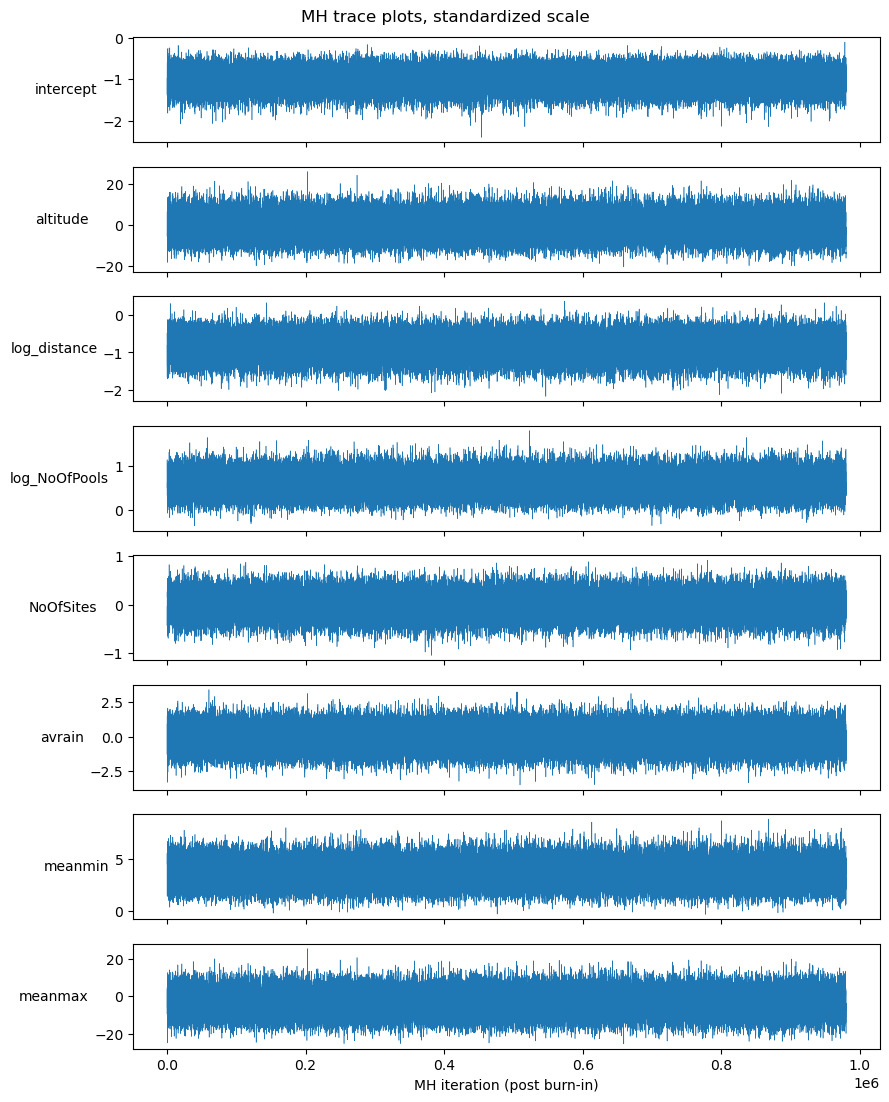

In [ ]:
# Diagnostics: trace plots and effective sample size

def effective_sample_size(x, max_lag=2000):
    """Crude ESS from initial positive sequence of autocorrelations."""
    n   = len(x)
    x0  = x - x.mean()
    var = np.var(x0)
    if var == 0:
        return n
    acf_sum = 0.0
    for lag in range(1, min(max_lag, n // 4)):
        c = np.mean(x0[:-lag] * x0[lag:]) / var
        if c < 0.05:
            break
        acf_sum += c
    return n / (1 + 2 * acf_sum)

ess_vals = np.array([effective_sample_size(post_samples[:, j]) for j in range(p)])

print("Effective sample size per coefficient:")
for j, name in enumerate(names):
    mcse = mh_sd_std[j] / np.sqrt(ess_vals[j])
    print(f"  {name:<14s} ESS ≈ {ess_vals[j]:7.0f}   MCSE(mean) ≈ {mcse:.4f}")

fig, axes = plt.subplots(p, 1, figsize=(9, 1.4 * p), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(post_samples[:, j], lw=0.4)
    ax.set_ylabel(names[j], rotation=0, ha='right', va='center')
axes[-1].set_xlabel("MH iteration (post burn-in)")
plt.suptitle("MH trace plots, standardized scale")
plt.tight_layout()
plt.show()

**Reading the diagnostics.** All eight ESS values are between roughly
$3.5 \times 10^4$ and $3.7 \times 10^4$ — about 3.7% of the raw 980K
samples. That's reasonable for a vanilla RWMH chain. The Monte Carlo
standard errors on the posterior means are at most $\approx 0.03$ (for
`altitude` and `meanmax`, the two collinear ones with the widest posteriors)
and well below $0.01$ for everything else. So when we compare VI and
Laplace to the MH means below, any difference larger than $\approx 0.05$
is real and not Monte Carlo noise.


## 7. Three-way comparison: MH (truth) vs VI vs Laplace

With MH as ground truth, how close are VI and Laplace?
We compute the absolute error of each approximation relative to MH for both
the posterior mean and posterior sd, coefficient by coefficient.


In [ ]:
# Errors are measured against MH (treated as ground truth)
mean_err_vi      = np.abs(mean_vi      - mh_mean_std)
mean_err_laplace = np.abs(np.asarray(beta_mle_std) - mh_mean_std)

sd_err_vi      = np.abs(sd_vi          - mh_sd_std)
sd_err_laplace = np.abs(sd_laplace_std - mh_sd_std)

comparison_full = pd.DataFrame({
    "coefficient": names,
    "MH_mean":     mh_mean_std,
    "VI_mean":     mean_vi,
    "Laplace_mean": np.asarray(beta_mle_std),
    "|VI - MH| mean":      mean_err_vi,
    "|Laplace - MH| mean": mean_err_laplace,
    "MH_sd":     mh_sd_std,
    "VI_sd":     sd_vi,
    "Laplace_sd": sd_laplace_std,
    "|VI - MH| sd":      sd_err_vi,
    "|Laplace - MH| sd": sd_err_laplace,
})

print("Comparison on standardized scale (MH = ground truth):")
display(comparison_full.round(4))

print("\nSummed absolute error over all coefficients:")
print(f"  Means:  VI = {mean_err_vi.sum():.4f},  Laplace = {mean_err_laplace.sum():.4f}")
print(f"  SDs:    VI = {sd_err_vi.sum():.4f},  Laplace = {sd_err_laplace.sum():.4f}")

Comparison on standardized scale (MH = ground truth):


,coefficient,MH_mean,VI_mean,Laplace_mean,|VI - MH| mean,|Laplace - MH| mean,MH_sd,VI_sd,Laplace_sd,|VI - MH| sd,|Laplace - MH| sd
0,intercept,-1.0016,-1.0018,-0.9292,0.0002,0.0724,0.2195,0.2139,0.2103,0.0055,0.0092
1,altitude,-0.5769,-0.2156,-0.8314,0.3613,0.2544,4.9900,4.9125,4.8349,0.0775,0.1552
2,log_distance,-0.8412,-0.8461,-0.7885,0.0048,0.0527,0.2737,0.2714,0.2652,0.0024,0.0085
3,log_NoOfPools,0.5893,0.5906,0.5608,0.0013,0.0286,0.2191,0.2152,0.2117,0.0039,0.0074
4,NoOfSites,-0.0082,-0.0103,-0.0017,0.0021,0.0064,0.2139,0.2122,0.2081,0.0017,0.0057
5,avrain,-0.0854,-0.0456,-0.0815,0.0399,0.0039,0.7457,0.7379,0.7197,0.0078,0.0259
6,meanmin,3.5968,3.6021,3.3240,0.0053,0.2728,1.0037,0.9849,0.9667,0.0189,0.0371
7,meanmax,-3.4137,-3.0272,-3.4481,0.3865,0.0344,5.4347,5.3568,5.2593,0.0780,0.1754



Summed absolute error over all coefficients:
  Means:  VI = 0.8014,  Laplace = 0.7257
  SDs:    VI = 0.1958,  Laplace = 0.4244


**The headline numbers (from the printed output):**

| metric | VI total error | Laplace total error |
|---|---:|---:|
| posterior **means**  | 0.80 | **0.73** |
| posterior **sds**    | **0.20** | 0.42 |

So **Laplace edges out VI on means** while **VI clearly beats Laplace on
sds** (roughly half the total error).

Looking coefficient-by-coefficient:

- **Six well-identified coefficients** (`intercept`, `log_distance`,
  `log_NoOfPools`, `NoOfSites`, `avrain`, `meanmin`): both methods are
  excellent. Mean errors are below 0.07 and sd errors below 0.04.
- **Two badly identified coefficients** (`altitude`, `meanmax`): both
  approximations show their largest errors here, but with opposite tendencies.
  - VI's mean for `altitude` is $-0.22$ vs MH's $-0.58$ (error $0.36$).
    Laplace gets $-0.83$, which overshoots by $0.25$.
  - VI's mean for `meanmax` is $-3.03$ vs MH's $-3.41$ (error $0.39$).
    Laplace gets $-3.45$, which is essentially spot-on (error $0.03$).

  The bias in VI is the well-known "**mode-seeking**" tendency of
  $\mathrm{KL}(q\Vert p)$: when the posterior is wide along a direction,
  $q$ would rather sit slightly inside the bulk than stretch out to cover
  the tails, so its marginal mean shrinks toward zero. Laplace, anchored at
  the MAP, doesn't have this pull — but it pays for that with sd errors that
  are 2–3× worse on these same two coefficients ($0.16$ and $0.18$ vs VI's
  $0.08$).

- **VI sds are uniformly closer to MH** for every single coefficient. The
  intuition: Laplace is a *local* quadratic at the mode, which underestimates
  variance whenever the true posterior has heavier-than-Gaussian tails. VI
  optimizes the global KL and so accounts for some of that tail mass.


### Visual check: posterior marginals

We overlay the MH histogram (treated as truth) with the VI Gaussian (solid)
and the Laplace Gaussian (dashed) for each of the 8 coefficients. Look for
where the dashed and solid Gaussians peel away from the histogram — that
is, where Gaussian-ness fails the data.


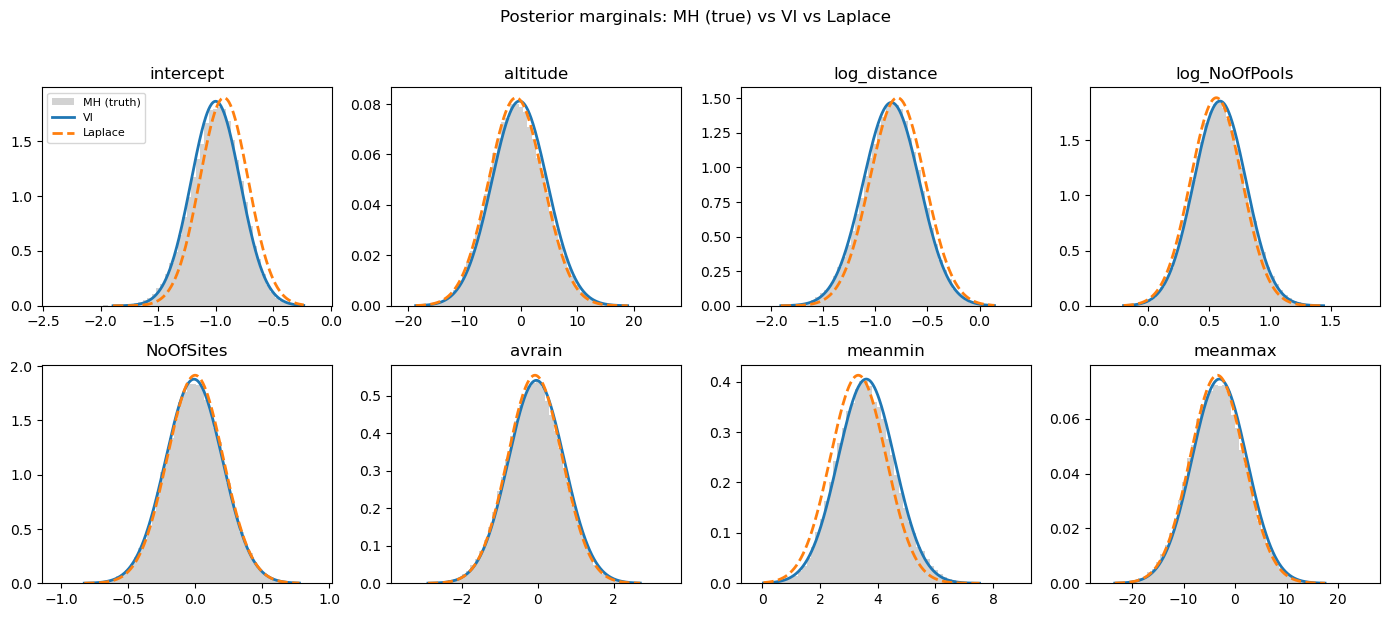

In [ ]:
# Visual comparison: posterior marginals (MH histogram) overlaid with
# VI and Laplace Gaussian densities
from scipy.stats import norm

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for j, ax in enumerate(axes.ravel()):
    if j >= p:
        ax.axis('off'); continue
    samp = post_samples[:, j]
    lo, hi = np.percentile(samp, [0.1, 99.9])
    pad = 0.1 * (hi - lo)
    grid = np.linspace(lo - pad, hi + pad, 400)

    ax.hist(samp, bins=60, density=True, alpha=0.35,
            color='gray', label='MH (truth)')
    ax.plot(grid, norm.pdf(grid, mean_vi[j],          sd_vi[j]),
            lw=2, label='VI')
    ax.plot(grid, norm.pdf(grid, np.asarray(beta_mle_std)[j], sd_laplace_std[j]),
            lw=2, ls='--', label='Laplace')
    ax.set_title(names[j])
    if j == 0:
        ax.legend(fontsize=8)
plt.suptitle("Posterior marginals: MH (true) vs VI vs Laplace", y=1.02)
plt.tight_layout()
plt.show()

**What the histograms reveal.** For most coefficients the histogram is
visibly Gaussian and both VI and Laplace track it nearly perfectly. The
exceptions are again `altitude` and `meanmax`: their histograms are slightly
*shifted* relative to the Gaussian fits — VI is centered a bit too far
right, Laplace too far left — and their tails are a touch heavier than
either Gaussian. That is a more honest picture than the table alone: the
true posterior in those directions is *not quite Gaussian*, and that's the
fundamental obstacle no Gaussian approximation can fully overcome on this
dataset.


## 8. Original-scale comparison

We repeat the three-way comparison after transforming everything back to the
original predictor scale. The transformation is the same linear map $A$ as
before — applied to the MH samples directly (then re-summarized), to the VI
mean and covariance analytically, and to Laplace via the refit GLM.

Because the transformation is linear, the *ranking* of approximation errors
is preserved up to scale: any coefficient where VI was closer to MH on the
standardized scale is still closer on the original scale, and likewise for
Laplace. The final two lines tally the wins.


In [ ]:
# ============================================================
# Transform MH, VI, and Laplace summaries back to original scale
# using the same linear map
# ============================================================

d = len(X_mean)

A = np.zeros((d + 1, d + 1))

# alpha_orig = alpha_std - sum_j gamma_j * mean_j / sd_j
A[0, 0] = 1.0
A[0, 1:] = -X_mean.values / X_sd.values

# beta_j_orig = gamma_j / sd_j
A[1:, 1:] = np.diag(1.0 / X_sd.values)


# ------------------------------------------------------------
# MH posterior samples on original scale
# ------------------------------------------------------------

mh_orig_samples = post_samples @ A.T

mh_orig_mean = mh_orig_samples.mean(axis=0)
mh_orig_cov = np.cov(mh_orig_samples, rowvar=False)
mh_orig_sd = np.sqrt(np.diag(mh_orig_cov))


# ------------------------------------------------------------
# VI posterior approximation on original scale
# ------------------------------------------------------------

vi_orig_mean = A @ mean_vi
vi_orig_cov = A @ cov_vi @ A.T
vi_orig_sd = np.sqrt(np.diag(vi_orig_cov))


# ------------------------------------------------------------
# Laplace approximation on original scale
# ------------------------------------------------------------

laplace_orig_mean = logistic_model_orig.params.values
laplace_orig_sd = logistic_model_orig.bse.values


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

original_full = pd.DataFrame({
    "coefficient": names,

    "MH_mean": mh_orig_mean,
    "VI_mean": vi_orig_mean,
    "Laplace_mean": laplace_orig_mean,

    "MH_sd": mh_orig_sd,
    "VI_sd": vi_orig_sd,
    "Laplace_sd": laplace_orig_sd,

    "|VI - MH| mean": np.abs(vi_orig_mean - mh_orig_mean),
    "|Laplace - MH| mean": np.abs(laplace_orig_mean - mh_orig_mean),

    "|VI - MH| sd": np.abs(vi_orig_sd - mh_orig_sd),
    "|Laplace - MH| sd": np.abs(laplace_orig_sd - mh_orig_sd),
})

print("Comparison on original predictor scale (MH = ground truth):")
display(original_full.round(4))


# ------------------------------------------------------------
# Which approximation wins, coefficient by coefficient?
# ------------------------------------------------------------

vi_wins_mean = (
    np.abs(vi_orig_mean - mh_orig_mean)
    <
    np.abs(laplace_orig_mean - mh_orig_mean)
)

vi_wins_sd = (
    np.abs(vi_orig_sd - mh_orig_sd)
    <
    np.abs(laplace_orig_sd - mh_orig_sd)
)

print(f"\nVI mean closer to MH on {vi_wins_mean.sum()}/{p} coefficients")
print(f"VI sd   closer to MH on {vi_wins_sd.sum()}/{p} coefficients")

Comparison on original predictor scale (MH = ground truth):


,coefficient,MH_mean,VI_mean,Laplace_mean,MH_sd,VI_sd,Laplace_sd,|VI - MH| mean,|Laplace - MH| mean,|VI - MH| sd,|Laplace - MH| sd
0,intercept,36.2197,26.4020,40.8988,137.1242,135.0924,132.6631,9.8177,4.6791,2.0318,4.4611
1,altitude,-0.0046,-0.0017,-0.0066,0.0399,0.0393,0.0387,0.0029,0.0020,0.0006,0.0012
2,log_distance,-0.8101,-0.8147,-0.7593,0.2636,0.2613,0.2554,0.0047,0.0508,0.0023,0.0082
3,log_NoOfPools,0.6019,0.6032,0.5727,0.2238,0.2198,0.2162,0.0013,0.0292,0.0040,0.0076
4,NoOfSites,-0.0042,-0.0053,-0.0009,0.1104,0.1095,0.1074,0.0011,0.0033,0.0009,0.0030
5,avrain,-0.0071,-0.0038,-0.0068,0.0622,0.0615,0.0600,0.0033,0.0003,0.0007,0.0022
6,meanmin,5.7402,5.7486,5.3048,1.6019,1.5717,1.5427,0.0084,0.4354,0.0301,0.0592
7,meanmax,-3.1413,-2.7856,-3.1730,5.0011,4.9293,4.8397,0.3557,0.0316,0.0718,0.1614



VI mean closer to MH on 4/8 coefficients
VI sd   closer to MH on 8/8 coefficients
